In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector
import numpy as np

db = mysql.connector.connect(host="localhost",username = "root",password = "1234",database = "ecommerce")
cur = db.cursor()

Basic Queries
1. List all unique cities where customers are located.
2. Count the number of orders placed in 2017.
3. Find the total sales per category.
4. Calculate the percentage of orders that were paid in installments.
5. Count the number of customers from each state

List all unique cities where customers are located.

In [43]:
query1 = """ select distinct customer_city from customers """
cur.execute(query1)
data1 = cur.fetchall()
df = pd.DataFrame(data1)
df.head()

,0
0,franca
1,sao bernardo do campo
2,sao paulo
3,mogi das cruzes
4,campinas


Count the number of orders placed in 2017

In [44]:
query2 = """ select count(*) from orders where year(order_purchase_timestamp) = 2017"""
cur.execute(query2)
data2 = cur.fetchall()
"total orders placed in 2017 are",data2[0][0]

('total orders placed in 2017 are', 45101)

Find the total sales per category.

In [45]:
query3 = """  select upper(products.product_category) as category, 
round(sum(payments.payment_value),3) as sales 
from products join order_items on products.product_id = order_items.product_id 
join payments on payments.order_id = order_items.order_id group by category"""
cur.execute(query3)
data3 = cur.fetchall()
df = pd.DataFrame(data3, columns = ["Category","Sales"])
df

,Category,Sales
0,PERFUMERY,506738.660
1,FURNITURE DECORATION,1430176.392
2,TELEPHONY,486882.051
3,BED TABLE BATH,1712553.671
4,AUTOMOTIVE,852294.331
...,...,...
69,CDS MUSIC DVDS,1199.430
70,LA CUISINE,2913.530
71,FASHION CHILDREN'S CLOTHING,785.670
72,PC GAMER,2174.430


Calculate the percentage of orders that were paid in installments

In [46]:
query4 = """ select (sum(case when payment_installments>=1 then 1 else 0 end))/count(*)*100 from payments"""
cur.execute(query4)
data4 = cur.fetchall()
("total percentage of orders that were paid in installments are",data4[0][0])

('total percentage of orders that were paid in installments are',
 Decimal('99.9981'))

Count the number of customers from each state

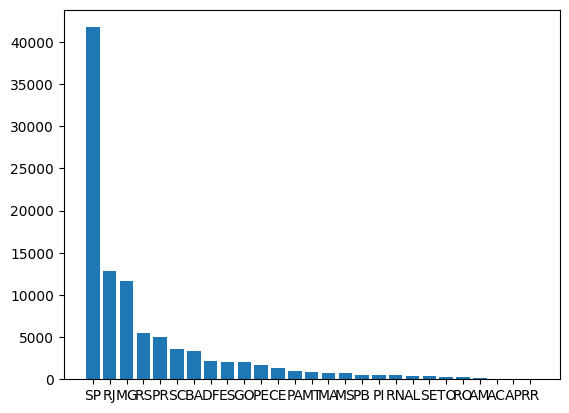

<Figure size 1000x400 with 0 Axes>

In [47]:
query5 = """ select customer_state,count(*) from customers group by customer_state"""
cur.execute(query5)
data5 = cur.fetchall()
df = pd.DataFrame(data5,columns = ["State","TotalCustomers"])
df = df.sort_values(by = "TotalCustomers",ascending = False)
plt.bar(df["State"],df["TotalCustomers"])
plt.figure(figsize = (10,4))
plt.show()

Intermediate Queries
1. Calculate the number of orders per month in 2018.
2. Find the average number of products per order, grouped by customer city.
3. Calculate the percentage of total revenue contributed by each product category.
4. Identify the correlation between product price and the number of times a product has been purchased.
5. Calculate the total revenue generated by each seller, and rank them by revenue.

Calculate the number of orders per month in 2018.

In [48]:
query6 = """ select count(*) as total_orders,month(ecommerce.orders.order_purchase_timestamp) as order_month
from orders where year(ecommerce.orders.order_purchase_timestamp) = 2018 
group by month(ecommerce.orders.order_purchase_timestamp) ORDER BY order_month"""
cur.execute(query6)
data6 = cur.fetchall()
df = pd.DataFrame(data6,columns = ["TotalOrders","month"])
# o = ["January","February","March","April","May","June","July","August","September","October","November","December"]
# sns.barplot(x = df["month"],y = df["TotalOrders"],data = df, order = o)
# plt.show()
df


,TotalOrders,month
0,7269,1
1,6728,2
2,7211,3
3,6939,4
4,6873,5
5,6167,6
6,6292,7
7,6512,8
8,16,9
9,4,10


Find the average number of products per order, grouped by customer city.

In [49]:
query7 = """ with count_per_order as (select ecommerce.orders.order_id, ecommerce.orders.customer_id, 
count(ecommerce.order_items.order_id) as oc from orders join order_items on 
orders.order_id =  order_items.order_id group by orders.order_id, orders.customer_id)
select customers.customer_city, round(avg(count_per_order.oc),0) as avg_count from customers join count_per_order on
customers.customer_id = count_per_order.customer_id 
group by customers.customer_city order by avg_count desc"""
cur.execute(query7)
data7 = cur.fetchall()
df = pd.DataFrame(data7, columns = ["City","Avg_order_value"])
df.head(10)

,City,Avg_order_value
0,celso ramos,7
1,padre carvalho,7
2,datas,6
3,candido godoi,6
4,matias olimpio,5
5,inconfidentes,4
6,morro de sao paulo,4
7,teixeira soares,4
8,curralinho,4
9,cidelandia,4


Calculate the percentage of total revenue contributed by each product category.

In [3]:
query8 = """ select upper(products.product_category) as category, 
round(sum(payments.payment_value)/(select sum(payment_value) from payments)*100,2) as contribution 
from products join order_items on products.product_id = order_items.product_id 
join payments on payments.order_id = order_items.order_id group by category order by contribution desc"""
cur.execute(query8)
data8 = cur.fetchall()
df = pd.DataFrame(data8, columns = ["Category","Contibution"])
df.head(5)

,Category,Contibution
0,BED TABLE BATH,10.70
1,HEALTH BEAUTY,10.35
2,COMPUTER ACCESSORIES,9.90
3,FURNITURE DECORATION,8.93
4,WATCHES PRESENT,8.93


Identify the correlation between product price and the number of times a product has been purchased.

In [51]:
query9 = """ select products.product_category, count(order_items.product_id), round(avg(order_items.price),2)
from products join order_items on products.product_id = order_items.product_id
group by products.product_category"""
cur.execute(query9)
data9 = cur.fetchall()
df = pd.DataFrame(data9,columns = ["Product","Product_Count","Avg_Price"])
arr1 = df["Product_Count"]
arr2 = df["Avg_Price"]
np.corrcoef([arr1],[arr2])

array([[ 1.        , -0.10631514],
       [-0.10631514,  1.        ]])

Calculate the total revenue generated by each seller, and rank them by revenue.

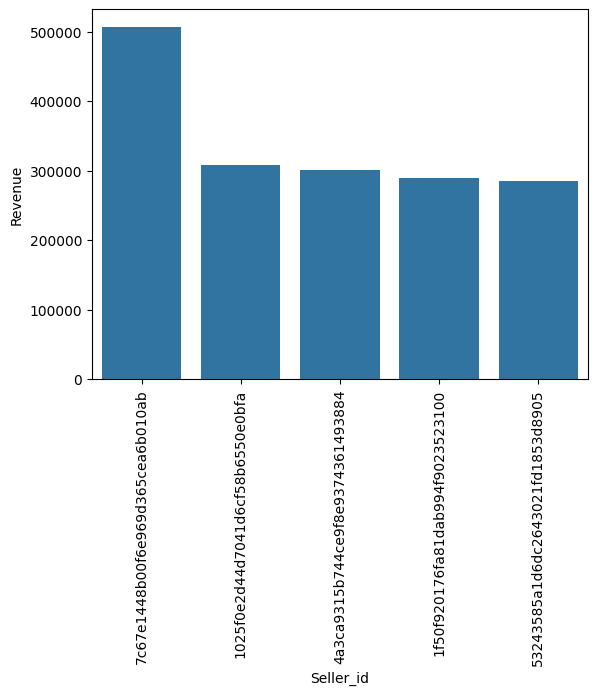

In [52]:
query10 = """select *, dense_rank() over (order by revenue desc) as rn from 
(select order_items.seller_id, sum(payments.payment_value) as revenue from 
order_items join payments on 
order_items.order_id = payments.order_id group by order_items.seller_id) as a;"""
cur.execute(query10)
data10 = cur.fetchall()
df = pd.DataFrame(data10,columns = ["Seller_id","Revenue","Rank"])
df = df.head(5)
sns.barplot(x = "Seller_id",y = "Revenue", data = df)
plt.xticks(rotation = 90)
plt.show()

Advanced Queries
1. Calculate the moving average of order values for each customer over their order history.
2. Calculate the cumulative sales per month for each year.
3. Calculate the year-over-year growth rate of total sales.
4. Calculate the retention rate of customers, defined as the percentage of customers who make another purchase within 6 months of their first purchase.
5. Identify the top 3 customers who spent the most money in each year.

Calculate the moving average of order values for each customer over their order history.

In [53]:
query11 = """select customer_id, order_purchase_timestamp,payments,
avg(payments) over (partition by customer_id order by order_purchase_timestamp
rows between 2 preceding and current row) as moving_avg from
(select orders.customer_id, orders.order_purchase_timestamp, 
payments.payment_value as payments from orders join 
payments on payments.order_id = orders.order_id) as a order by moving_avg desc"""
cur.execute(query11)
data11 = cur.fetchall()
df= pd.DataFrame(data11,columns = ["OrderId","Timestamp","Payments","MovingAvg"])
df

,OrderId,Timestamp,Payments,MovingAvg
0,1617b1357756262bfa56ab541c47bc16,2017-09-29 15:24:52,13664.10,13664.080078
1,ec5b2ba62e574342386871631fafd3fc,2018-07-15 14:49:44,7274.88,7274.879883
2,c6e2731c5b391845f6800c97401a43a9,2017-02-12 20:37:36,6929.31,6929.310059
3,f48d464a0baaea338cb25f816991ab1f,2018-07-25 18:10:17,6922.21,6922.209961
4,3fd6777bbce08a352fddd04e4a7cc8f6,2017-05-24 18:14:34,6726.66,6726.660156
...,...,...,...,...
103881,430ec51e3c42def76f0d79a8edb21784,2017-10-13 12:58:35,0.01,0.010000
103882,3532ba38a3fd242259a514ac2b6ae6b6,2018-08-28 15:26:39,0.00,0.000000
103883,f2def7f64f36952f2f5a9791f0285f34,2018-01-24 23:24:14,0.00,0.000000
103884,197a2a6a77da93f678ea0d379f21da0a,2018-08-28 20:05:14,0.00,0.000000


Calculate the cumulative sales per month for each year.

In [4]:
query12 = """ select years,months,payments,sum(payments) over (order by years,months) as cummulative_sales from
(select year(orders.order_purchase_timestamp) as years, 
month(orders.order_purchase_timestamp) as months, 
round(sum(payments.payment_value),2) as payments from orders 
join payments on orders.order_id = payments .order_id
group by years, months order by years,months) as a """
cur.execute(query12)
data12 = cur.fetchall()
df = pd.DataFrame(data12,columns = ["year","months","payment","cummulative_sales"])
df.head(5)

,year,months,payment,cummulative_sales
0,2016,9,252.24,252.24
1,2016,10,59090.48,59342.72
2,2016,12,19.62,59362.34
3,2017,1,138488.04,197850.38
4,2017,2,291908.01,489758.39


Calculate the year-over-year growth rate of total sales.

In [60]:
query13 = """ with a as (select year(orders.order_purchase_timestamp) as years,  
round(sum(payments.payment_value),2) as payments from orders 
join payments on orders.order_id = payments .order_id
group by years order by years)
select years,((payments-lag(payments,1) over (order by years))/ lag(payments,1) over (order by years))*100 from a"""
cur.execute(query13)
data13 = cur.fetchall()
df = pd.DataFrame(data13,columns = ["Year","year-by-year-growth%"])
df

,Year,year-by-year-growth%
0,2016,NaN
1,2017,12112.703761
2,2018,20.000924


Calculate the retention rate of customers, defined as the percentage of customers who make another purchase within 6 months of their first purchase.

In [62]:
query14 = """ with a as (select customers.customer_id, min(orders.order_purchase_timestamp) as first_order
from customers join orders on 
customers.customer_id = orders.customer_id group by customers.customer_id),
b as (select a.customer_id, count(distinct(orders.order_purchase_timestamp)) as next_order
from a join orders on orders.customer_id = a.customer_id 
and orders.order_purchase_timestamp > first_order
and orders.order_purchase_timestamp < date_add(first_order,interval 6 month)
group by a.customer_id)
select 100* (count(distinct a.customer_id)/count(distinct b.customer_id))
from a left join b on a.customer_id = b.customer_id; """
cur.execute(query14)
data14 = cur.fetchall()
data14

[(None,)]

Identify the top 3 customers who spent the most money in each year.

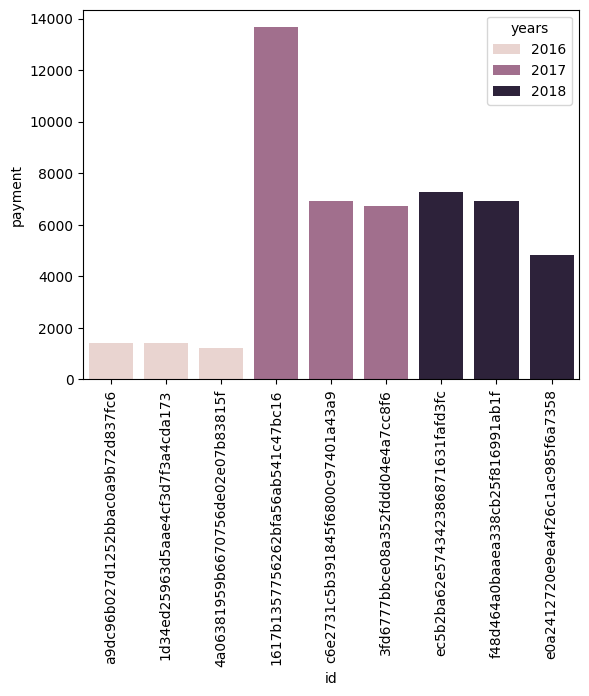

In [70]:
query15 = """select years, customer_id,payment,d_rank from
(select year(orders.order_purchase_timestamp) years,orders.customer_id, 
sum(payments.payment_value) as payment,
dense_rank() over ( partition by year(orders.order_purchase_timestamp) 
order by sum(payments.payment_value) desc) as d_rank
from orders join payments on payments.order_id = orders.order_id 
group by year(orders.order_purchase_timestamp),orders.customer_id,orders.order_id) as a
where d_rank <=3"""
cur.execute(query15)
data15 = cur.fetchall()
df= pd.DataFrame(data15,columns = ["years","id","payment","d_rank"])
sns.barplot(x = "id",y = "payment",data = df, hue = "years")
plt.xticks(rotation = 90)
plt.show()

Basic Queries

1.List all unique cities where customers are located.
2.Count the number of orders placed in 2017.
3.Find the total sales per category.
4.Calculate the percentage of orders that were paid in installments.
5.Count the number of customers from each state.